<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# Clase Práctica: Aprendizaje Profundo (Deep Learning) aplicado a la Visión por Computador
**Dirigido a:** Físicos, Astrónomos e Ingenieros Físicos  
**Duración Estimada:** 1 hora y 30 minutos  
**Temas Principales:** Redes Convolucionales (CNN), Detección de Objetos (YOLO / Bounding Boxes), Métricas de Validación (IoU, Precisión, Reclamo) y Detección de Anomalías.  

---

## Estructura de la Clase y Objetivos
1. **Módulo 1: Convoluciones y Extracción de Atributos** (25 min) - Entender la operación de convolución discreta como un extractor de características físicas (bordes, gradientes).
2. **Módulo 2: Detección de Objetos y Geometría de Superposición** (30 min) - Estudiar las cajas delimitadoras (*Bounding Boxes*) y evaluar su precisión mediante la intersección sobre la unión ($IoU$).
3. **Módulo 3: Detección de Anomalías Estadísticas** (25 min) - Conceptos de reconstrucción de imágenes y aislamiento de desviaciones (Simulación de fallas en sensores o datos experimentales).
4. **Discusión y Cierre** (10 min).

---

In [1]:
# ==========================================
# CELDA DE CONFIGURACIÓN INICIAL (EJECUTAR)
# ==========================================
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Entorno de Deep Learning e Instrumentación Computacional cargado con éxito.")

Entorno de Deep Learning e Instrumentación Computacional cargado con éxito.


---
## Módulo 1: Redes Neuronales Convolucionales (CNN) - El Operador de Convolución (25 min)

En física o procesamiento de señales, la convolución en el espacio continuo $(f * g)(t)$ es un operador fundamental. En imágenes digitales (tensores discretos de orden 2), una **capa convolucional** aplica una matriz pequeña de pesos llamada **Kernel** o filtro a lo largo de toda la matriz de la imagen.

A diferencia del enfoque tradicional (*Handcrafted Features*), donde un ingeniero diseña el kernel (como los filtros de Sobel), en **Deep Learning** los pesos del kernel se **aprenden** de manera automática mediante el algoritmo de *Backpropagation* basándose en el error de la clasificación.

$$\mathbf{S}(i,j) = (I * K)(i,j) = \sum_{m} \sum_{n} I(i-m, j-n) K(m,n)$$

### Ejercicio 1: Simulación de Extracción de Características Mediante Convolución
Vamos a generar un "objeto físico artificial" (un disco brillante simulando una estrella o una sección transversal de una partícula) y le aplicaremos convoluciones con diferentes núcleos para observar cómo las primeras capas de una CNN aíslan gradientes espaciales y texturas.

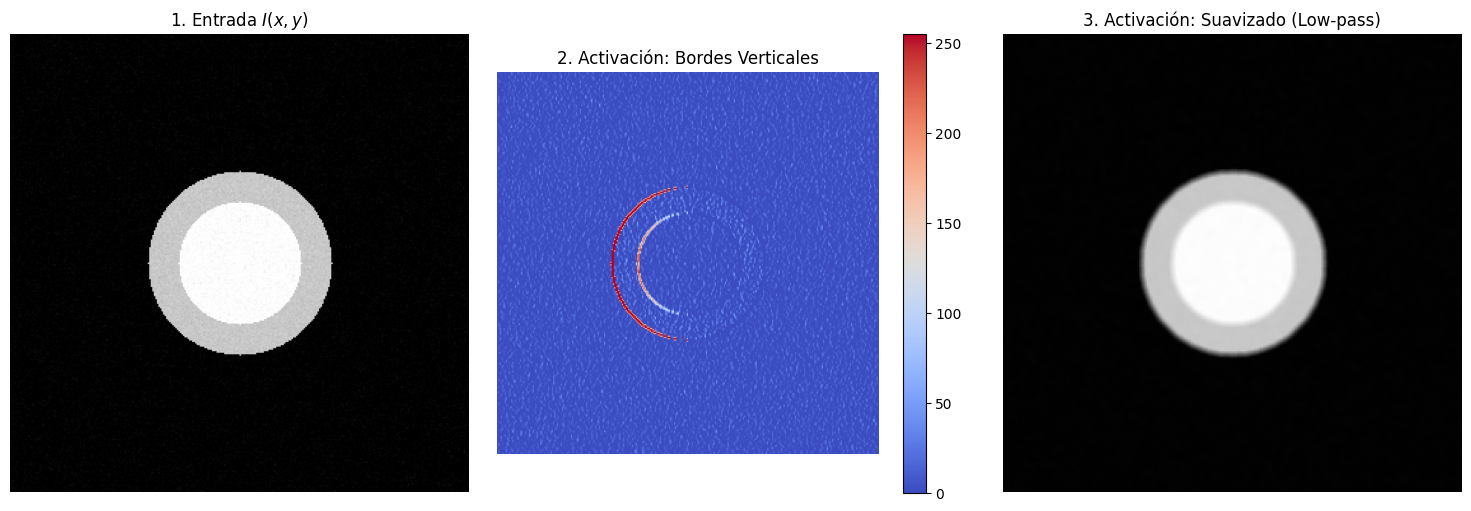

In [2]:
# EJERCICIO 1: Código Python

def simular_extraccion_cnn():
    # Crear un fondo oscuro (espacio profundo) con un objeto circular en el centro
    img = np.zeros((300, 300), dtype=np.float32)
    cv2.circle(img, (150, 150), 60, 200, -1) # Estructura sólida
    cv2.circle(img, (150, 150), 40, 255, -1) # Núcleo de alta intensidad

    # Añadir un poco de ruido gaussiano simulando fluctuaciones térmicas del detector
    ruido = np.random.normal(0, 5, img.shape)
    img = np.clip(img + ruido, 0, 255).astype(np.uint8)

    # Definir dos kernels que simulan lo que aprendería una CNN en sus primeras capas:
    # Kernel A: Extractor de bordes verticales (Filtro Sobel X)
    kernel_vertical = np.array([[-1, 0, 1],
                                [-2, 0, 2],
                                [-1, 0, 1]], dtype=np.float32)

    # Kernel B: Filtro de suavizado y desenfoque (Operador de integración local Gaussiana)
    kernel_suave = np.ones((5, 5), dtype=np.float32) / 25.0

    # Aplicar convoluciones discretas
    capa_bordes = cv2.filter2D(img, -1, kernel_vertical)
    capa_suave  = cv2.filter2D(img, -1, kernel_suave)

    # Visualización de los mapas de activación (Feature Maps)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("1. Entrada $I(x,y)$")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("2. Activación: Bordes Verticales")
    plt.imshow(capa_bordes, cmap='coolwarm')
    plt.colorbar()
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("3. Activación: Suavizado (Low-pass)")
    plt.imshow(capa_suave, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

simular_extraccion_cnn()

---
## Módulo 2: Detección de Objetos (YOLO) y la Métrica de Validación $IoU$ (30 min)

Modelos como **YOLO (You Only Look Once)** resuelven simultáneamente dos problemas en una sola pasada por la red:
1. **Clasificación:** ¿Qué objeto hay en la región?
2. **Localización:** ¿Cuáles son las coordenadas de su caja delimitadora o *Bounding Box*? Una caja se define comúnmente por $[x_{centro}, y_{centro}, ancho, alto]$.

Para evaluar si la predicción de una IA es matemáticamente aceptable, comparamos la caja predicha con la verdad de campo (*Ground Truth*) usando el índice de Jaccard o **Intersección sobre la Unión ($IoU$)**:

$$IoU = \frac{\text{Área de la Intersección}}{\text{Área de la Unión}}$$

Una predicción se suele clasificar como **Verdadero Positivo (TP)** si su $IoU > 0.5$ (o un umbral predefinido).

### Ejercicio 2: Cálculo Geométrico de la Métrica $IoU$
Implementaremos el cálculo analítico de $IoU$ a nivel de píxeles y simularemos visualmente el solapamiento entre una medición manual (Ground Truth) y la salida numérica de un detector tipo YOLO.

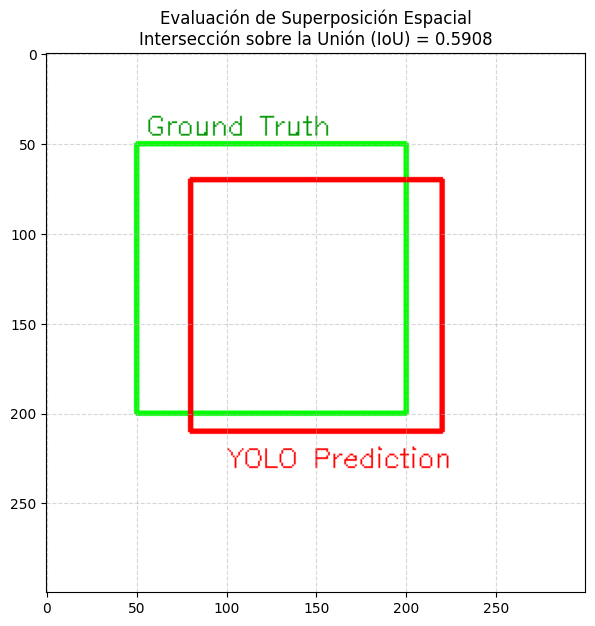

In [3]:
# EJERCICIO 2: Código Python

def calcular_iou(boxA, boxB):
    """
    Calcula el IoU de dos cajas en formato [x1, y1, x2, y2] (esquinas sup-izq e inf-der).
    """
    # Determinar las coordenadas de la intersección
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Calcular el área de la intersección
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # Calcular el área de ambas cajas
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBAArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    # Calcular la unión
    unionArea = float(boxAArea + boxBAArea - interArea)

    # Retornar el IoU
    return interArea / unionArea

# Definir coordenadas sintéticas
# Formato: [x_min, y_min, x_max, y_max]
ground_truth = [50, 50, 200, 200]
prediccion_ia = [80, 70, 220, 210]

iou_resultado = calcular_iou(ground_truth, prediccion_ia)

# Generar canvas para visualización geométrica
canvas = np.ones((300, 300, 3), dtype=np.uint8) * 255

# Dibujar las cajas sobre el lienzo
cv2.rectangle(canvas, (ground_truth[0], ground_truth[1]), (ground_truth[2], ground_truth[3]), (0, 255, 0), 2)  # Verde
cv2.rectangle(canvas, (prediccion_ia[0], prediccion_ia[1]), (prediccion_ia[2], prediccion_ia[3]), (255, 0, 0), 2) # Azul

# Añadir etiquetas de texto
cv2.putText(canvas, "Ground Truth", (55, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 150, 0), 1)
cv2.putText(canvas, "YOLO Prediction", (100, 230), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.figure(figsize=(7, 7))
plt.title(f"Evaluación de Superposición Espacial\nIntersección sobre la Unión (IoU) = {iou_resultado:.4f}")
plt.imshow(canvas)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## Módulo 3: Detección de Anomalías (25 min)

En entornos de control de calidad o análisis de datos científicos (como la búsqueda de defectos en materiales mediante Rayos X o fallas en componentes electrónicos), una **Anomalía** se define como una desviación estadística respecto al patrón considerado "normal".

Un enfoque común utilizando Deep Learning consiste en entrenar un Autoencoder o una red generativa (GAN) **únicamente con datos normales**. Cuando el modelo procesa una imagen normal, es capaz de reconstruirla con un error mínimo. Sin embargo, si la imagen de entrada contiene una anomalía (un elemento extraño no visto en el entrenamiento), el modelo fallará al intentar reconstruirla. Al calcular la **diferencia absoluta** (residuo) entre la entrada y la reconstrucción, la anomalía se manifiesta con un alto nivel de energía en el mapa de residuos.

<>:39: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_5129/3642006596.py:39: SyntaxWarning: invalid escape sequence '\D'
  plt.title("3. Mapa de Residuos Magnitud $|\Delta I|$")


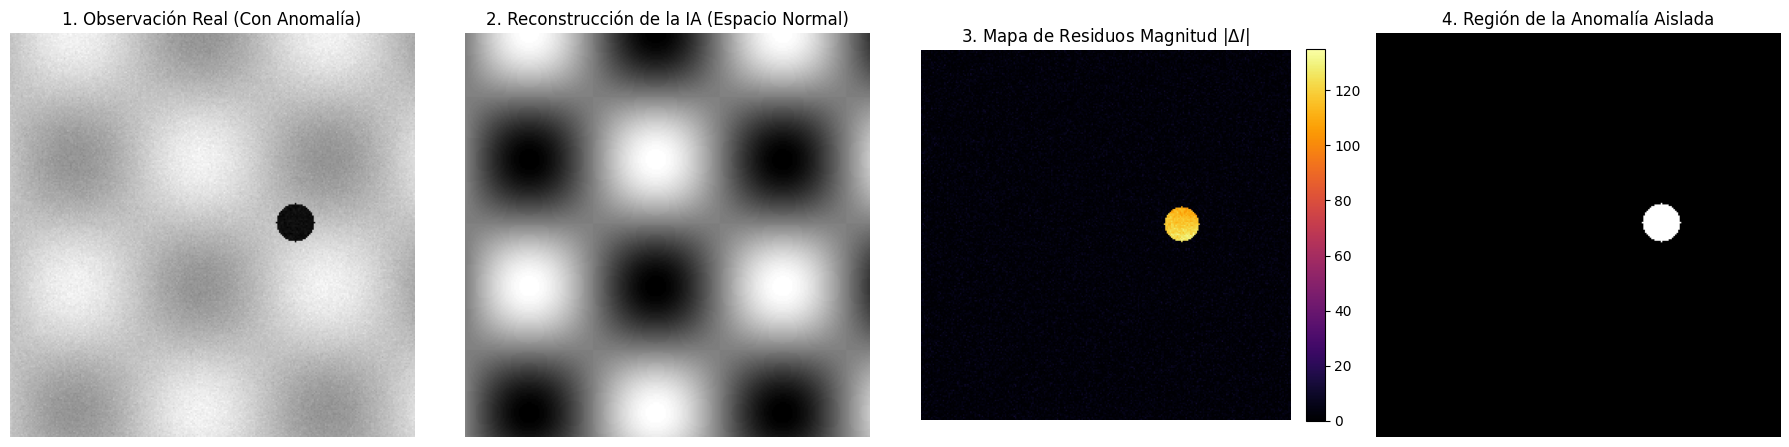

In [4]:
# EJERCICIO 3: Código Python

def simular_deteccion_anomalias():
    # 1. Generar la señal de control ideal (Superficie homogénea perfecta)
    x = np.linspace(0, 10, 256)
    y = np.linspace(0, 10, 256)
    X, Y = np.meshgrid(x, y)
    patron_normal = (np.sin(X) * np.cos(Y) * 30 + 128).astype(np.uint8)

    # 2. Simular la imagen observada en el laboratorio con un defecto ("Anomalía" estructural)
    imagen_con_defecto = patron_normal.copy()
    # Insertamos un patrón anómalo de alta densidad (un impacto o fractura exógena)
    cv2.circle(imagen_con_defecto, (180, 120), 12, 10, -1)
    # Añadir ruido aleatorio del sistema físico
    imagen_con_defecto = cv2.addGaussianNoise = np.clip(imagen_con_defecto + np.random.normal(0, 3, patron_normal.shape), 0, 255).astype(np.uint8)

    # 3. Simular la salida del modelo de IA (El Autoencoder reconstruye el patrón normal que aprendió)
    reconstruccion_ia = patron_normal.copy() # La IA no sabe reconstruir el círculo negro, reconstruye la señal base

    # 4. Calcular el mapa de residuos (Diferencia física absoluta)
    mapa_residuos = cv2.absdiff(imagen_con_defecto, reconstruccion_ia)

    # Aplicar un umbral estadístico para aislar y segmentar la anomalía
    _, anomalia_detectada = cv2.threshold(mapa_residuos, 35, 255, cv2.THRESH_BINARY)

    # Renderizar el flujo analítico completo
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 4, 1)
    plt.title("1. Observación Real (Con Anomalía)")
    plt.imshow(imagen_con_defecto, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("2. Reconstrucción de la IA (Espacio Normal)")
    plt.imshow(reconstruccion_ia, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("3. Mapa de Residuos Magnitud $|\Delta I|$")
    plt.imshow(mapa_residuos, cmap='inferno')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("4. Región de la Anomalía Aislada")
    plt.imshow(anomalia_detectada, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

simular_deteccion_anomalias()

---
## Módulo 4: Ejercicio de Discusión e Interpretación Científica (10 min)

**Preguntas de análisis para los Físicos e Ingenieros de la clase:**

1. En el **Ejercicio 2**, si reducimos las dimensiones de la caja predicha por la IA a la mitad pero manteniendo exactamente su mismo centro geométrico, ¿el valor de la métrica $IoU$ decaerá de forma lineal o no lineal? Deduce la expresión geométrica del cambio del área respecto al factor de escala.
2. Pensando en el método de detección de anomalías del **Ejercicio 3**: si la señal del sensor sufriera un incremento repentino de temperatura incrementando severamente el ruido térmico de fondo (gaussiano), ¿cómo afectaría esto al mapa de residuos y al umbral de binarización utilizado para detectar la anomalía estructural? ¿Cómo lo resolverías matemáticamente?